In [1]:
import os 
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
MASTER_DIR = Path(r"D:\Automotive\Race Strategy Decision Support System (RSDSS)\Race-Strategy-Decision-Support-System-RSDSS-\Data\Processed\Master\Master_Dataset.csv")
df = pd.read_csv(MASTER_DIR)

In [3]:
df = df[df["ValidLap"]].copy()

In [4]:
print(df["Circuit"].nunique())
print(sorted(df["Circuit"].unique()))

26
['Austin', 'Baku', 'Barcelona', 'Budapest', 'Imola', 'Jeddah', 'Las Vegas', 'Le Castellet', 'Lusail', 'Marina Bay', 'Melbourne', 'Mexico City', 'Miami', 'Miami Gardens', 'Monaco', 'Montréal', 'Monza', 'Sakhir', 'Shanghai', 'Silverstone', 'Spa-Francorchamps', 'Spielberg', 'Suzuka', 'São Paulo', 'Yas Island', 'Zandvoort']


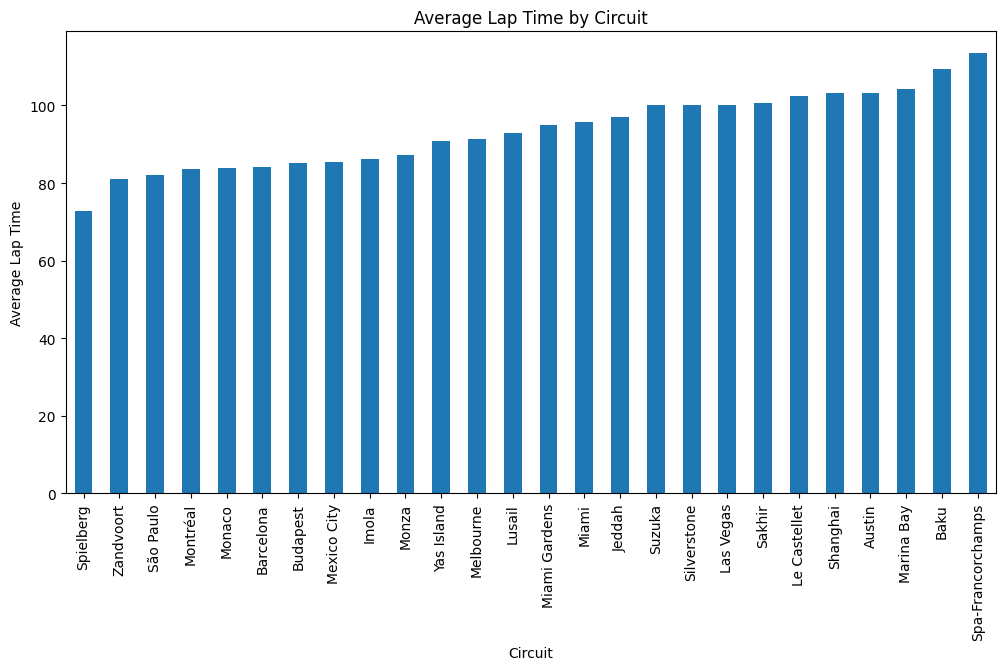

In [5]:
avg = (
    df.groupby("Circuit")["LapTime_Seconds"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
avg.plot(kind="bar")

plt.ylabel("Average Lap Time")

plt.title("Average Lap Time by Circuit")

plt.show()

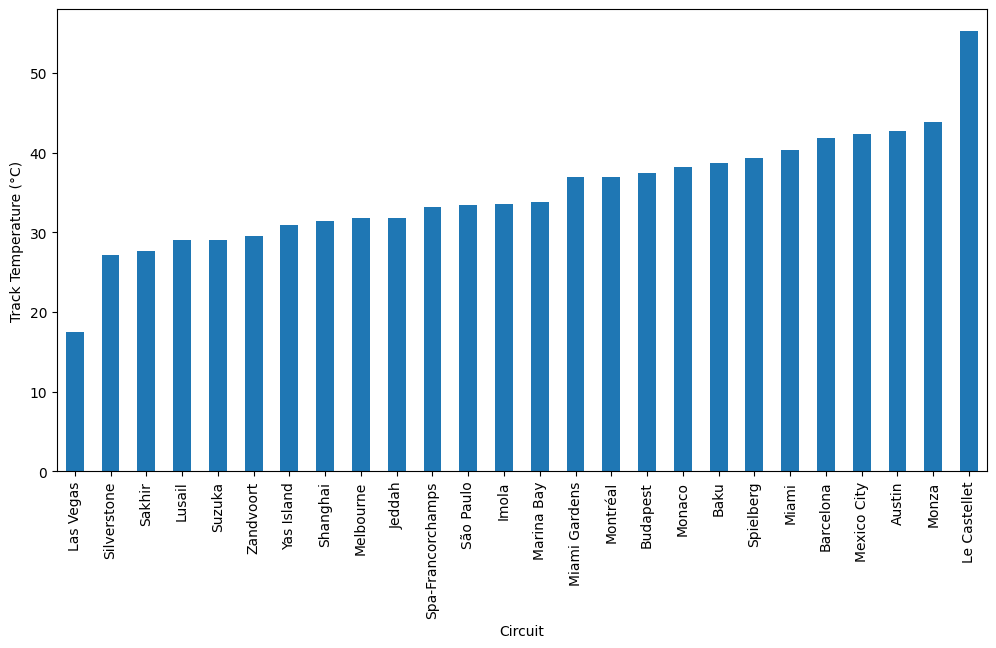

In [6]:
track_temp = (
    df.groupby("Circuit")["TrackTemp"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
track_temp.plot(kind="bar")

plt.ylabel("Track Temperature (°C)")

plt.show()

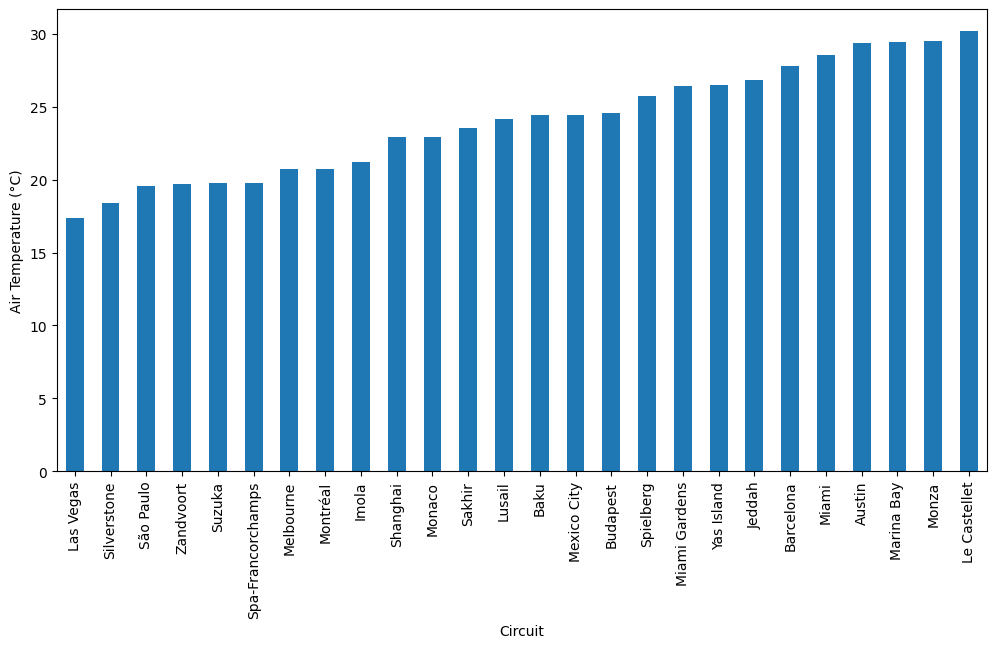

In [7]:
air_temp = (
    df.groupby("Circuit")["AirTemp"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
air_temp.plot(kind="bar")

plt.ylabel("Air Temperature (°C)")

plt.show()

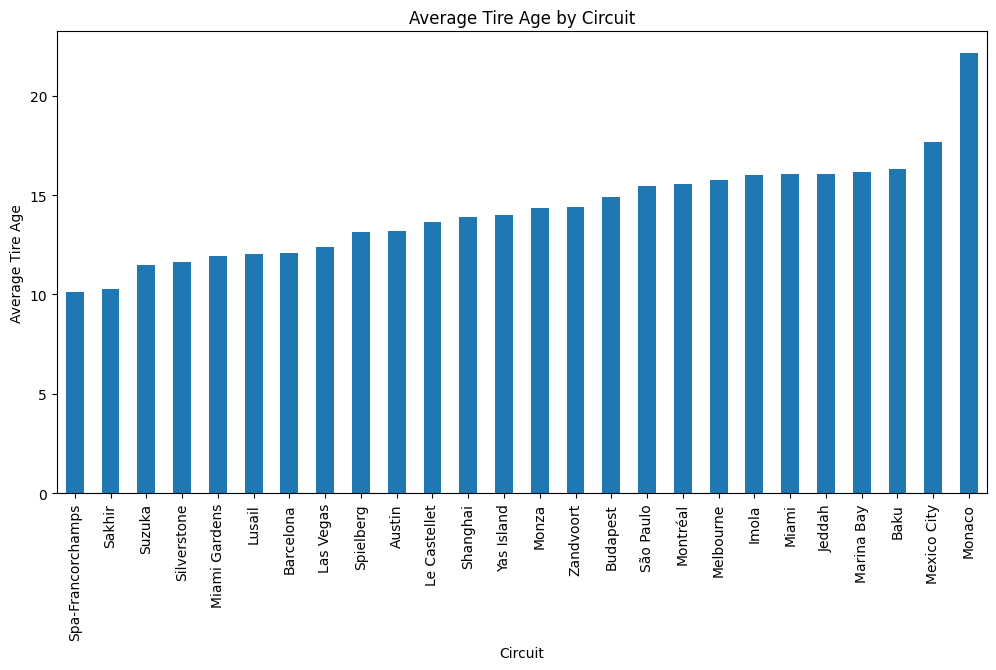

In [8]:
age = (
    df.groupby("Circuit")["TireAge"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
age.plot(kind="bar")

plt.ylabel("Average Tire Age")

plt.title("Average Tire Age by Circuit")

plt.show()

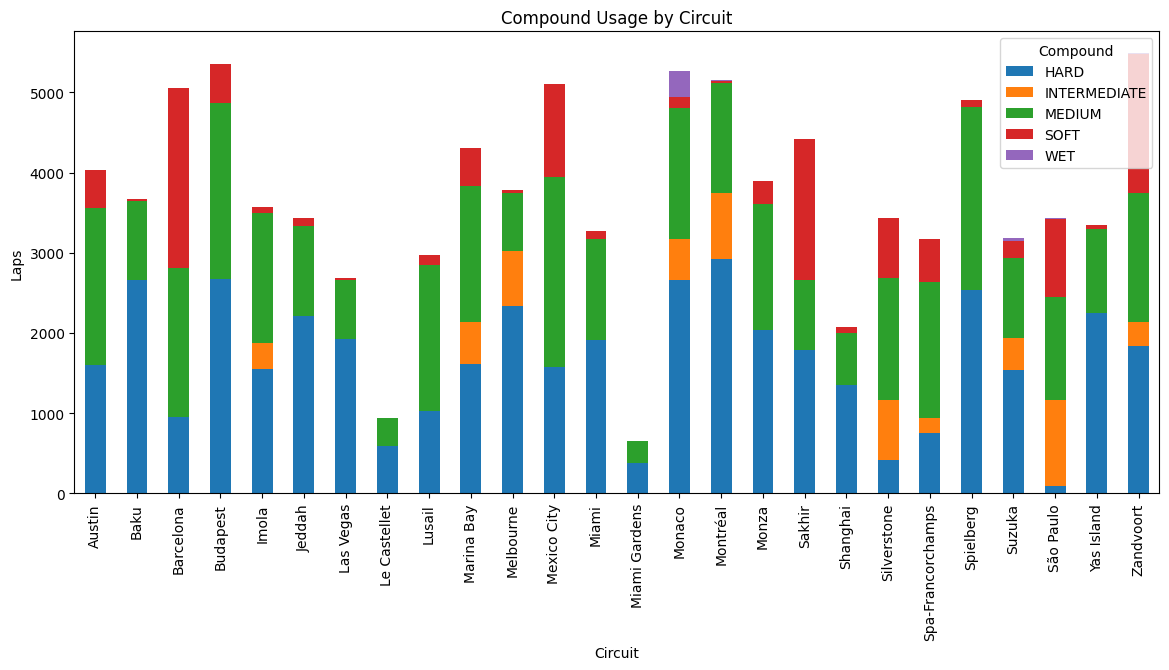

In [9]:
compound = pd.crosstab(
    df["Circuit"],
    df["Compound"]
)

compound.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.ylabel("Laps")

plt.title("Compound Usage by Circuit")

plt.show()

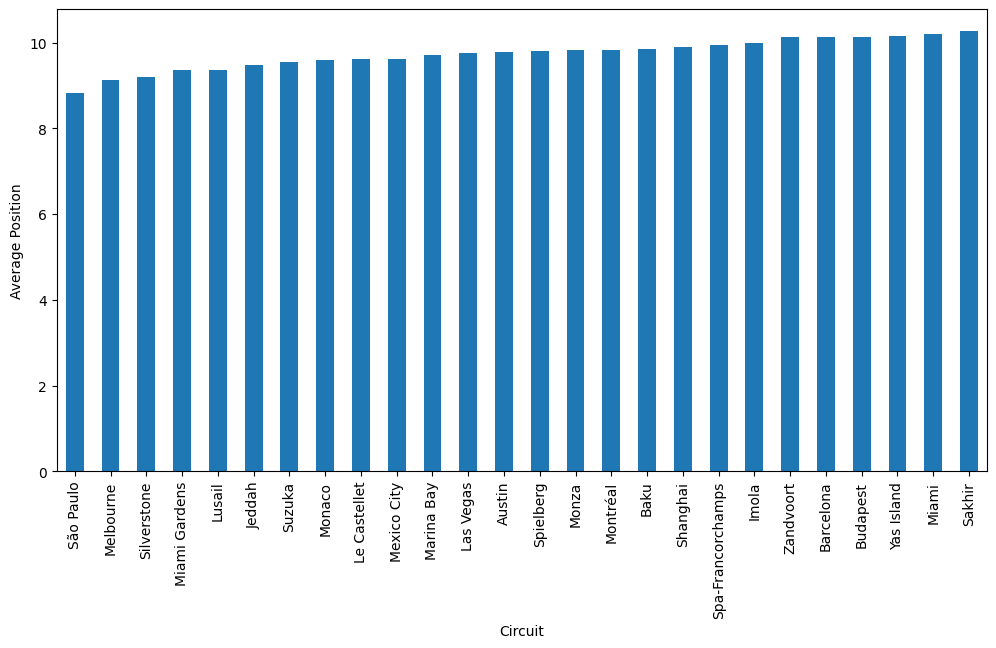

In [10]:
position = (
    df.groupby("Circuit")["Position"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
position.plot(kind="bar")

plt.ylabel("Average Position")

plt.show()

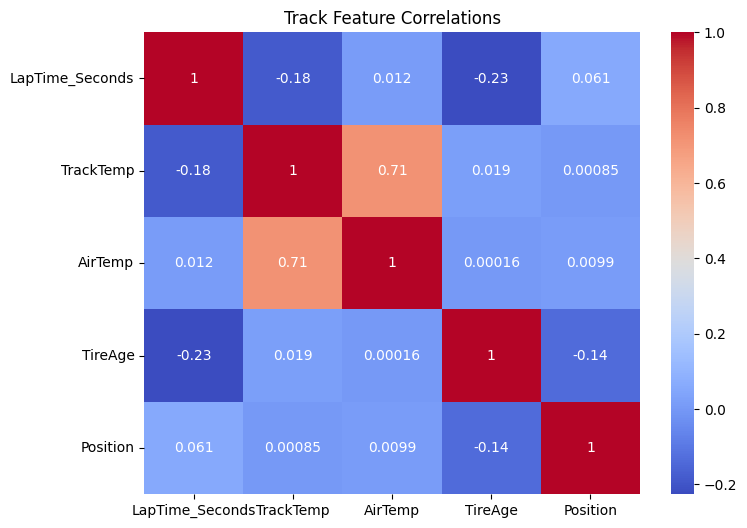

In [11]:
corr = df[
    [
        "LapTime_Seconds",
        "TrackTemp",
        "AirTemp",
        "TireAge",
        "Position"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Track Feature Correlations")

plt.show()

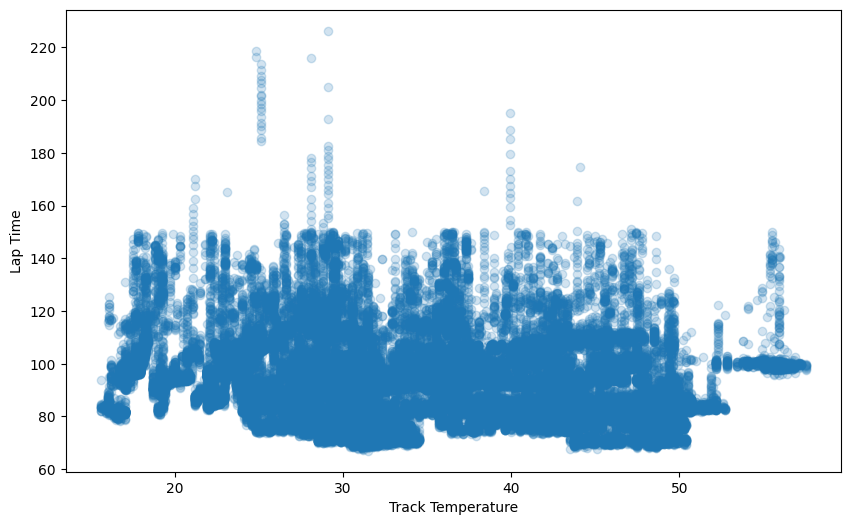

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["TrackTemp"],
    df["LapTime_Seconds"],
    alpha=0.2
)

plt.xlabel("Track Temperature")
plt.ylabel("Lap Time")

plt.show()

## Conclusion

- Circuit characteristics strongly influence lap times, tire age, and operating temperatures.
- Some circuits consistently exhibit higher tire degradation than others.
- Environmental conditions vary substantially between circuits and seasons.
- Circuit information is therefore an essential feature for tire degradation prediction.